# 04b · SODAs — discovering the full Differential-Algebraic system

The Michaelis–Menten mechanism

$$E + S \;\underset{k_r}{\overset{k}{\rightleftharpoons}}\; ES \;\xrightarrow{k_{cat}}\; E + P$$

is, under quasi-steady state, a **DAE**: differential laws for the dynamic species *plus*
algebraic constraints linking all four. With $k=k_r=k_{cat}=1$ and total enzyme $E_0=1$, the
**true system** is

$$
\textbf{differential:}\quad \dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES] \\
\textbf{algebraic:}\quad [E]+[ES]=1 \;\;(\text{enzyme conservation}), \qquad
[S][E]=2\,[ES] \;\;(\text{QSSA / steady state}).
$$

**SODAs** (Jayadharan et al., *Proc. R. Soc. A* 2026) discovers this exactly the way the
reference **`DaeFinder`** walkthrough does, in five stages:

1. **discover the conservation law** — *without knowing it in advance*: `AlgModelFinder`
   regresses every variable on the others and ranks the candidates by $R^2$;
2. **refine** the candidate library — drop every term containing the now-redundant `[E]`;
3. **discover the QSSA** relation by running the *same finder* on the refined library;
4. **refine again** — drop the redundant `[S][ES]` term — and **discover the dynamics**;
5. use an **SVD** of the library to *count* how many independent algebraic relations there are.

Finding the algebraic relations first and using them to shrink the library is what keeps the
recovered model physically structured, where one-shot regression drowns in the redundancy the
constraints create.

In [1]:
# --- Environment setup -------------------------------------------------------
# Same requirements as notebook 04: DaeFinder + pandas, sympy, scikit-learn, matplotlib.
# Install everything ONCE (uncomment a line and run it):
#
#   !pip install -r ../requirements.txt        # full tutorial environment, or:
#   !pip install DaeFinder pandas sympy scikit-learn matplotlib
#
import importlib.util
_required = ["daeFinder", "pandas", "sympy", "sklearn", "numpy", "matplotlib"]
_missing = [m for m in _required if importlib.util.find_spec(m) is None]
if _missing:
    raise ImportError(
        "Missing required packages: " + ", ".join(_missing) + ".\n"
        "Run (once):  pip install -r ../requirements.txt\n"
        "        or:  pip install DaeFinder pandas sympy scikit-learn matplotlib"
    )
print("Environment OK -", ", ".join(_required), "are importable.")

Environment OK - daeFinder, pandas, sympy, sklearn, numpy, matplotlib are importable.


In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path: sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# --- DaeFinder compatibility shim: PEP 667 + read-only-array safe -------------
# Patches get_refined_lib, get_simplified_equation and get_simplified_equation_list.
# Run BEFORE the `from daeFinder import ...` below.
from sparse_demos.daefinder_compat import patch as _patch_daefinder
_patch_daefinder()
# Pull the *safe* simplification helpers from the shim (the daeFinder originals raise
# on modern pandas); get_refined_lib is re-exported from daeFinder after patching.
from sparse_demos.daefinder_compat import (get_simplified_equation_list,
                                           get_simplified_equation)

## Data: a Michaelis–Menten enzyme assay (multiple substrate levels)

Like a real enzyme assay, we run the **same enzyme** ($E_0=1$, fixed rates) at **several
initial substrate concentrations** $S_0$. This matters: a *single* trajectory admits many
spurious algebraic relations, but the **true** relations are the ones that hold across **all**
trajectories. The QSSA relation is initial-condition–independent, and enzyme conservation
shares the same $E_0$ — so both become identifiable, while substrate totals (which differ per
run) are correctly *not* flagged as universal.

`smooth_data` fits a spline to each trajectory and returns the smoothed states together with
their time derivatives (`d([S]) /dt`, `d([P]) /dt`); `noise_perc=0` here (clean data).

In [4]:
import pandas as pd
from daeFinder import (solveMM, smooth_data, PolyFeatureMatrix,
                       AlgModelFinder, sequentialThLin,
                       get_refined_lib, remove_paranth_from_feat,
                       construct_reduced_fit_list)

k_rates = pd.Series({"k": 1.0, "kr": 1.0, "kcat": 1.0})
S0_list = [1.0, 2.0, 3.0, 4.0, 5.0]
species = ["[S]", "[E]", "[ES]", "[P]"]
tg = np.linspace(0, 4, 40)

smooth_list = []
for S0 in S0_list:
    IC = pd.Series({"S": S0, "P": 0.0, "E": 1.0})
    df = pd.DataFrame(solveMM(IC, k_rates, tg, "demo"), columns=species)
    df["[t]"] = tg
    smooth_list.append(smooth_data(df, domain_var="[t]", derr_order=1,
                                   noise_perc=0, eval_points=tg))
smooth_app = pd.concat(smooth_list, ignore_index=True)
state = smooth_app[species]            # smoothed state columns only
print("stacked samples:", state.shape[0], "| species:", species)

stacked samples: 200 | species: ['[S]', '[E]', '[ES]', '[P]']


## Candidate library .

In [5]:
import sympy
data_df = state.copy()
S, E, ES, P = sympy.symbols(list(data_df.columns))   # symbols match column names

lib_full = PolyFeatureMatrix(degree=3).fit_transform(state).drop(["1"], axis=1)
print("degree-3 library terms (%d):" % lib_full.shape[1])
print(list(lib_full.columns))
print("\n(degree-2 had only 14 terms; the extra 20 are the cubic monomials that create the "
      "product-redundancy.)")

degree-3 library terms (34):
['[S]', '[E]', '[ES]', '[P]', '[S]^2', '[S] [E]', '[S] [ES]', '[S] [P]', '[E]^2', '[E] [ES]', '[E] [P]', '[ES]^2', '[ES] [P]', '[P]^2', '[S]^3', '[S]^2 [E]', '[S]^2 [ES]', '[S]^2 [P]', '[S] [E]^2', '[S] [E] [ES]', '[S] [E] [P]', '[S] [ES]^2', '[S] [ES] [P]', '[S] [P]^2', '[E]^3', '[E]^2 [ES]', '[E]^2 [P]', '[E] [ES]^2', '[E] [ES] [P]', '[E] [P]^2', '[ES]^3', '[ES]^2 [P]', '[ES] [P]^2', '[P]^3']

(degree-2 had only 14 terms; the extra 20 are the cubic monomials that create the product-redundancy.)


### A discovery helper

`discover_relation` is the heart of SODAs and mirrors the walkthrough: it hands a candidate
library to `AlgModelFinder`, which regresses **every** column on the others, ranks the fits by
$R^2$, and returns the **best** relation — we read off *which* variable ended up on the
left-hand side and *which* terms are active, then refit those exactly with ordinary least
squares. Nothing about the relations is assumed in advance.

In [6]:
import io, contextlib
from sklearn.linear_model import LinearRegression

def discover_relation(finder_lib, refit_lib, fit_intercept, thr=0.1):
    # Returns (lhs, rhs, ols_model, ranked_r2, best_models_df).
    seq = sequentialThLin(model_id="LR", coef_threshold=thr, fit_intercept=fit_intercept)
    finder = AlgModelFinder(custom_model=True, custom_model_ob=seq)
    with contextlib.redirect_stdout(io.StringIO()):      # hush per-column convergence prints
        finder.fit(finder_lib, scale_columns=True)
    best_models_df = finder.best_models()
    ranked_r2 = best_models_df.loc["r2- metric"].sort_values(ascending=False)
    best = finder.best_models(1)
    lhs = best.columns[0]
    coefs = best[lhs].drop("r2- metric", errors="ignore")
    rhs = list(coefs[coefs.abs() > thr].index)
    ols = LinearRegression(fit_intercept=fit_intercept).fit(refit_lib[rhs], refit_lib[lhs])
    return lhs, rhs, ols, ranked_r2, best_models_df

## Stage 1 — conservation law (degree-independent)

Conservation is linear, so the degree-3 library makes no difference here: the finder again ranks
`[E]` and `[ES]` at $R^2\approx1$ — the enzyme-conservation law $[E]+[ES]=E_0$.

In [7]:
lhs, rhs, ols, ranked, _ = discover_relation(state, state, fit_intercept=True)
print("Algebraic relations among the states, ranked by R^2:")
print(ranked.round(3).to_string())

E0 = ols.intercept_
print(f"\nTop relation discovered (LHS = {lhs}):")
print("  %s = %+.3f %s %+.3f   =>   %s + %s = %.3f   (enzyme conservation, true E_0 = 1)"
      % (lhs, ols.coef_[0], rhs[0], E0, lhs, rhs[0], E0))

Algebraic relations among the states, ranked by R^2:
[E]     1.000
[ES]    1.000
[S]     0.926
[P]     0.140

Top relation discovered (LHS = [E]):
  [E] = -1.000 [ES] +1.000   =>   [E] + [ES] = 1.000   (enzyme conservation, true E_0 = 1)


## Stage 2 — refine the library: drop `[E]`

Enzyme conservation makes `[E]` **redundant** ($[E]=E_0-[ES]$). SODAs therefore removes every
library term containing `[E]` with `get_refined_lib`. This both shrinks the search and
**rewrites** the remaining relations in terms of the kept variables.

In [8]:
dropped_E, refined_lib = get_refined_lib({E}, data_df, lib_full, get_dropped_feat=True)
print("dropped %d terms containing [E]." % len(dropped_E))
print("refined library (%d terms):" % refined_lib.shape[1], list(refined_lib.columns))

dropped 15 terms containing [E].
refined library (19 terms): ['[S]', '[ES]', '[P]', '[S]^2', '[S] [ES]', '[S] [P]', '[ES]^2', '[ES] [P]', '[P]^2', '[S]^3', '[S]^2 [ES]', '[S]^2 [P]', '[S] [ES]^2', '[S] [ES] [P]', '[S] [P]^2', '[ES]^3', '[ES]^2 [P]', '[ES] [P]^2', '[P]^3']


## Stage 3 — discover the QSSA relation 

Now run the finder on the refined degree-3 library. In notebook 04 (degree 2) the top relation was
the clean $[S]=2[ES]+[S][ES]$. At degree 3 the top relation is still ranked $R^2=1$ — but it picks
up **redundant cubic terms**:

$$[S] \approx 2\,[ES] + 0.37\,[S][ES] + 1.26\,[ES]^2 + 0.63\,[S][ES]^2.$$

Worse, a whole cluster of candidates (`[S]`, `[ES]`, `[S][ES]`, `[ES]^2`, …) all tie at $R^2=1$:
they are the **same QSSA relation multiplied by different monomials**. The discovery has become
**non-unique** — exactly the failure mode notebook 04 sidestepped. A raw OLS refit of the top pick
keeps the spurious terms.

In [9]:
lhs3, rhs3, ols3, ranked3, best_models_full = discover_relation(
    refined_lib, lib_full, fit_intercept=False)

print("Relations on the refined degree-3 library, ranked by R^2 (top 8):")
print(ranked3.head(8).round(4).to_string())

print(f"\nTop relation discovered (LHS = {lhs3})  -- note the redundant cubic terms:")
print("  %s = " % lhs3 + " + ".join("%.3f %s" % (c, n) for n, c in zip(rhs3, ols3.coef_)))
print("\n  The many R^2=1 ties are products of the SAME relation -> discovery is non-unique.")

Relations on the refined degree-3 library, ranked by R^2 (top 8):
[S]           1.0
[ES]          1.0
[S] [ES]      1.0
[S] [P]       1.0
[ES]^2        1.0
[ES] [P]      1.0
[S]^2 [ES]    1.0
[S] [ES]^2    1.0

Top relation discovered (LHS = [S])  -- note the redundant cubic terms:
  [S] = 2.000 [ES] + 0.833 [S] [ES] + 0.333 [ES]^2 + 0.167 [S] [ES]^2

  The many R^2=1 ties are products of the SAME relation -> discovery is non-unique.


## Stage 3b — **cancel the common factors** with the DaeFinder simplification tools

This is the new stage, lifted straight from the **`DaeFinder` Michaelis–Menten walkthrough**.
The idea is purely algebraic:

* `get_simplified_equation_list` takes every discovered relation `LHS = Σ cᵢ·termᵢ`, builds it as a
  **sympy** expression, and computes `sympy.cancel(rhs / lhs)` — dividing out any polynomial factor
  the two sides share. A relation whose LHS carries the redundant `[ES]` factor (say `[S][ES] = …`)
  loses that factor and **collapses to the fundamental form** $[S]=2[ES]+[S][ES]$.
* `construct_reduced_fit_list` reads the surviving monomials back as **library feature names**, so
  we can do a final exact OLS on the cleaned-up term set.

Note the asymmetry: the *top* pick `[S]=…` does **not** simplify — `[S]` shares no factor with its
redundant RHS, so `cancel` leaves it alone. But every discovered relation whose **LHS contains the
spurious `[ES]` factor** does cancel, and they all collapse to the same three-term relation. We let
the simplification run over **all** candidates and then pick the fundamental relation as the one
with the **fewest terms that still refits at $R^2\approx1$** (this rejects both the contaminated
5-term forms and any degenerate low-$R^2$ collapse).

In [11]:
# Run the simplification over every discovered relation. intercept ~ 0 here (fit_intercept=False),
# so cancellation of the common factor is exact.
intercept_dict = {c: 0.0 for c in best_models_full.columns}
simplified = get_simplified_equation_list(
    best_model_df=best_models_full.fillna(0)[:-1],   # drop the trailing "r2- metric" row
    coef_threshold=0.1, intercept_threshold=0.01,
    global_feature_list=data_df.columns,
    intercept_dict=intercept_dict, simplified=True)

reduced = construct_reduced_fit_list(best_models_full.fillna(0)[:-1], simplified_eqs=simplified)
cols = list(best_models_full.columns)

# Tabulate raw discovered LHS -> simplified relation -> reduced feature set.
rows = []
for lhs in ranked3.index:
    i = cols.index(lhs)
    feats = [f for f in reduced[i] if f is not None]
    eq = simplified[lhs]
    rows.append({"discovered_LHS": lhs,
                 "simplified_relation": f"{eq['lhs']} = {eq['rhs']}",
                 "n_terms": len(feats),
                 "reduced_features": tuple(feats)})
simp_table = pd.DataFrame(rows)
# print("How each discovered relation simplifies (top 8 by R^2):")
# with pd.option_context("display.max_colwidth", 60):
#     print(simp_table.head(8).to_string(index=False))

In [12]:
# Among the distinct simplified relations, keep those that still fit at R^2 ~ 1,
# then choose the one with the FEWEST terms -> the fundamental QSSA relation.
def _degree(feat):                      # crude monomial degree from the feature string
    return feat.count("[")

candidates = {}
for feats in simp_table["reduced_features"]:
    fs = frozenset(feats)
    if len(fs) < 2 or fs in candidates:
        continue
    ordered = sorted(fs, key=lambda f: (_degree(f), f))
    # Prefer reading the relation with [S] on the left, to match the ground truth / notebook 04.
    lhs_f = "[S]" if "[S]" in fs else ordered[0]
    rhs_f = [f for f in ordered if f != lhs_f]
    m = LinearRegression(fit_intercept=False).fit(lib_full[rhs_f], lib_full[lhs_f])
    candidates[fs] = dict(lhs=lhs_f, rhs=rhs_f, r2=m.score(lib_full[rhs_f], lib_full[lhs_f]),
                          coef=dict(zip(rhs_f, m.coef_)), n=len(fs))

good = {fs: v for fs, v in candidates.items() if v["r2"] > 0.9999}
fundamental = min(good.values(), key=lambda v: v["n"])

print("Fundamental algebraic relation recovered after simplification:")
terms = " + ".join("%.3f %s" % (c, n) for n, c in fundamental["coef"].items())
print(f"  {fundamental['lhs']} = {terms}   (R^2 = {fundamental['r2']:.5f})")
print("\n  i.e. the QSSA / steady-state law  [S][E] = 2[ES]  rewritten with [E] = 1 - [ES],")
print("  exactly the degree-2 result from notebook 04 -- the redundant cubic terms are gone.")

Fundamental algebraic relation recovered after simplification:
  [S] = 2.000 [ES] + 1.000 [S] [ES]   (R^2 = 1.00000)

  i.e. the QSSA / steady-state law  [S][E] = 2[ES]  rewritten with [E] = 1 - [ES],
  exactly the degree-2 result from notebook 04 -- the redundant cubic terms are gone.


## Stage 4 — refine again, then discover the dynamics

The QSSA relation makes `[S][ES]` redundant for the dynamics. Dropping `[E]` **and** `[S][ES]` from
the degree-3 library (every monomial divisible by either) leaves a library that no longer hides the
differential equations, and a thresholded fit against the spline derivatives recovers them cleanly
— same result as notebook 04, despite starting from degree 3.

In [13]:
dropped2, refined_dyn = get_refined_lib({E, S * ES}, data_df, lib_full, get_dropped_feat=True)
print("refined dynamic library (%d terms):" % refined_dyn.shape[1], list(refined_dyn.columns))
print()
for target, truth in [("d([S]) /dt", "-1.0 [ES]"), ("d([P]) /dt", "+1.0 [ES]")]:
    dyn = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=True)
    with contextlib.redirect_stdout(io.StringIO()):
        dyn.fit(X=refined_dyn, y=smooth_app[target])
    terms = {n: round(float(c), 3) for n, c in zip(dyn.feature_names_in_, dyn.coef_)
             if abs(c) > 1e-2}
    print(f"{target} = {terms}   (true: {truth})")

refined dynamic library (15 terms): ['[S]', '[ES]', '[P]', '[S]^2', '[S] [P]', '[ES]^2', '[ES] [P]', '[P]^2', '[S]^3', '[S]^2 [P]', '[S] [P]^2', '[ES]^3', '[ES]^2 [P]', '[ES] [P]^2', '[P]^3']

d([S]) /dt = {'[ES]': -1.0}   (true: -1.0 [ES])
d([P]) /dt = {'[ES]': 1.0}   (true: +1.0 [ES])


## Stage 5 — how many algebraic relations? The SVD view at degree 3

Each algebraic relation makes the library columns linearly dependent on the data manifold, so the
standardized library is rank-deficient and some singular values collapse toward zero. At **degree 3**
the redundancy is far larger than at degree 2, because every relation appears again multiplied by
each monomial:

* the **full** degree-3 library has **many** near-zero singular values (vs 6 at degree 2);
* dropping `{[E]}` removes the conservation redundancy but leaves the **whole QSSA family**
  (QSSA, $[S]\cdot$QSSA, $[ES]\cdot$QSSA, …) — so several near-zero values remain;
* dropping `{[E],\,[S][ES]}` removes the factor that *generates* that family, and the library
  reaches **full rank (zero near-zero values)**.

Reaching full rank in the **same two refinement steps** confirms there are still exactly **two**
independent algebraic relations — degree 3 multiplied the redundancy but added no new fundamental
constraint.

full degree-3 library                      cols=34  near-zero singular values (<1e-06): 19
after dropping {factors of [E]}            cols=19  near-zero singular values (<1e-06): 4
after dropping {[E], [S][ES] factors}      cols=15  near-zero singular values (<1e-06): 0


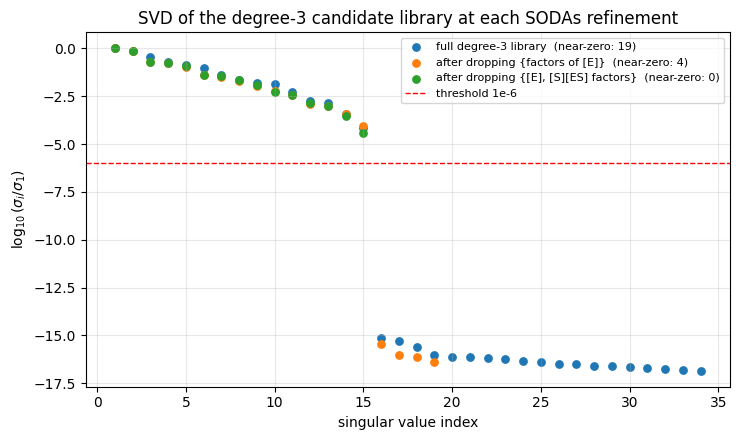


-> two refinements still drive the near-zero count to 0:
   degree 3 inflates the redundancy but the data support exactly TWO independent relations.


In [14]:
from sklearn.preprocessing import StandardScaler

def singular_values(df):
    M = StandardScaler().fit_transform(df)
    return np.linalg.svd(M, compute_uv=False)

stages = [("full degree-3 library", lib_full),
          ("after dropping {factors of [E]}", refined_lib),
          ("after dropping {[E], [S][ES] factors}", refined_dyn)]

rel_tol = 1e-6
plt.figure(figsize=(7.5, 4.5))
for label, df in stages:
    sv = singular_values(df)
    rel = sv / sv[0]
    n_zero = int((rel < rel_tol).sum())
    plt.scatter(np.arange(1, len(sv) + 1), np.log10(np.clip(rel, 1e-32, None)),
                label=f"{label}  (near-zero: {n_zero})", s=28)
    print(f"{label:42s} cols={df.shape[1]:2d}  near-zero singular values (<{rel_tol:g}): {n_zero}")
plt.axhline(np.log10(rel_tol), color="r", ls="--", lw=1, label=f"threshold 1e{int(np.log10(rel_tol))}")
plt.xlabel("singular value index")
plt.ylabel(r"$\log_{10}(\sigma_i / \sigma_1)$")
plt.title("SVD of the degree-3 candidate library at each SODAs refinement")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n-> two refinements still drive the near-zero count to 0:")
print("   degree 3 inflates the redundancy but the data support exactly TWO independent relations.")

## The full recovered DAE — identical to notebook 04

$$
\boxed{\;\dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES]\;}
\qquad\text{with}\qquad
\boxed{\;[E]+[ES]=1, \qquad [S][E]=2[ES]\;}
$$

**What changed going from degree 2 to degree 3.** The conservation law, the dynamics, and the
SVD rank count were all unaffected. The one place the extra degree bit was **algebraic discovery**:
the QSSA relation came back as a redundant, non-unique cubic member of its family. The
`DaeFinder` simplification tools — `get_simplified_equation_list` (which runs `sympy.cancel` to
divide out the common factor) and `construct_reduced_fit_list` (which maps the cleaned relation
back to library terms) — collapsed it to the fundamental $[S]=2[ES]+[S][ES]$, recovering exactly
the degree-2 answer.

**Takeaway.** You don't have to hand-tune the library degree to the minimal value. If you over-shoot
and the discovery returns a high-degree member of a relation, the symbolic *simplify → cancel →
refit* step is the principled cleanup: it cancels the redundant common factors and returns the
fundamental constraint. → back to `05_benchmark_comparison.ipynb`.